In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Config
RUNS_DIR = "../runs"  # Doctor AI spec directory
EMOTION_LABELS = ["angry", "disgust", "happy", "low_affect", "arousal"]  # Lowercase per spec

In [2]:
# 1. Load all visits from JSONL files

def load_all_visits(runs_dir):
    """
    Load all face.jsonl files from runs directory (Doctor AI spec v0.1).
    Returns a pandas DataFrame with all visits.
    """
    runs_path = Path(runs_dir)
    
    if not runs_path.exists():
        raise FileNotFoundError(f"Runs directory not found: {runs_dir}")
    
    records = []
    visit_dirs = sorted(runs_path.glob("visit_*"))
    
    if not visit_dirs:
        raise RuntimeError(f"No visit directories found in {runs_dir}")
    
    print(f"Found {len(visit_dirs)} visit directories")
    
    for visit_dir in visit_dirs:
        face_file = visit_dir / "face.jsonl"
        
        if not face_file.exists():
            print(f"[WARN] No face.jsonl in {visit_dir.name}, skipping")
            continue
        
        # Read JSONL file (may have multiple records, we want summary)
        with open(face_file, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    record = json.loads(line)
                    
                    # Only process summary records
                    if record.get("type") != "summary":
                        continue
                    
                    # Flatten for DataFrame
                    flat_record = {
                        "visit_id": record["visit_id"],
                        "patient_id": record["patient_id"],
                        "subsystem": record["subsystem"],
                        "phase": record["phase"],
                        "type": record["type"],
                        "t_start": record.get("t_start"),
                        "t_end": record.get("t_end"),
                        "confidence": record["confidence"],
                        "valid": record["valid"],
                        "schema_version": record.get("schema_version", "unknown"),
                        "model_version": record.get("model_version", "unknown"),
                    }
                    
                    # Extract features
                    features = record.get("features", {})
                    flat_record["total_samples"] = features.get("total_samples", 0)
                    flat_record["timestamp"] = features.get("timestamp", "")
                    flat_record["visit_label"] = features.get("visit_label", "")
                    
                    # Add emotion counts and percentages
                    emotion_counts = features.get("emotion_counts", {})
                    emotion_pct = features.get("emotion_pct", {})
                    
                    for emo in EMOTION_LABELS:
                        flat_record[f"{emo}_count"] = emotion_counts.get(emo, 0)
                        flat_record[f"{emo}_pct"] = emotion_pct.get(emo, 0.0)
                    
                    records.append(flat_record)
    
    if not records:
        raise RuntimeError("No valid summary records found in face.jsonl files")
    
    df = pd.DataFrame(records)
    return df

# Load data
df = load_all_visits(RUNS_DIR)
print(f"\nLoaded {len(df)} visits from {df['patient_id'].nunique()} patient(s)")
print(f"Schema versions: {df['schema_version'].unique()}")
print(f"Model versions: {df['model_version'].unique()}")

# Preview
df.head()

Found 2 visit directories

Loaded 2 visits from 1 patient(s)
Schema versions: ['v0.1']
Model versions: ['resnet34_5class_v3']


,visit_id,patient_id,subsystem,phase,type,t_start,t_end,confidence,valid,schema_version,...,angry_count,angry_pct,disgust_count,disgust_pct,happy_count,happy_pct,low_affect_count,low_affect_pct,arousal_count,arousal_pct
0,2026-03-11T08-43-10,SeanTest,face,encounter,summary,0.0,25.551045,1.0,True,v0.1,...,0,0.0,0,0.0,7,15.22,35,76.09,4,8.70
1,2026-03-11T08-55-37,SeanTest,face,encounter,summary,0.0,27.495419,1.0,True,v0.1,...,0,0.0,0,0.0,13,26.53,24,48.98,12,24.49


In [3]:
# 2. Visualize a single visit

# Pick a patient (change this to your patient ID)
patient_id = "SeanTest"  # ← CHANGE THIS

patient_visits = df[df["patient_id"] == patient_id].sort_values("timestamp")

if len(patient_visits) == 0:
    print(f"No visits found for patient: {patient_id}")
else:
    visit = patient_visits.iloc[-1]  # Get latest visit
    
    # Extract values
    emotion_labels = EMOTION_LABELS
    counts = [visit[f"{emo}_count"] for emo in emotion_labels]
    percents = [visit[f"{emo}_pct"] for emo in emotion_labels]
    
    print(f"Analyzing latest visit for patient: {patient_id}")
    print(f"  Visit ID: {visit['visit_id']}")
    print(f"  Visit label: {visit['visit_label']}")
    print(f"  Total samples: {visit['total_samples']}")
    print(f"  Duration: {visit['t_end'] if visit['t_end'] else 'unknown'}s")
    print(f"  Model: {visit['model_version']}")

Analyzing latest visit for patient: SeanTest
  Visit ID: 2026-03-11T08-55-37
  Visit label: 2026-03-11
  Total samples: 49
  Duration: 27.495419025421143s
  Model: resnet34_5class_v3


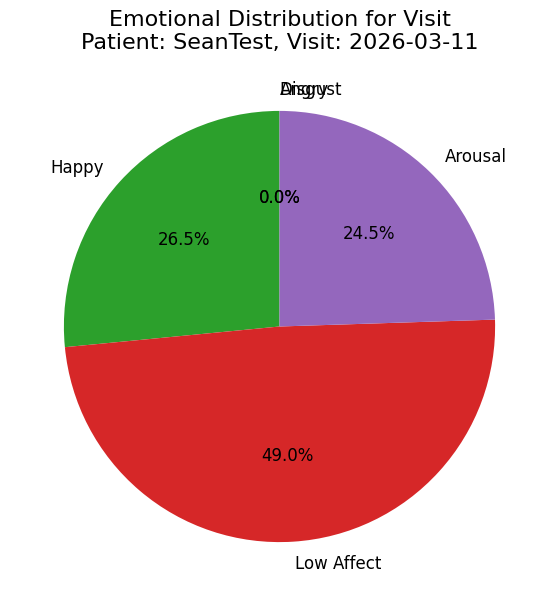

In [4]:
# Pie chart (percentage distribution)

# Make labels prettier for display
display_labels = [emo.replace('_', ' ').title() for emo in emotion_labels]

plt.figure(figsize=(7, 7))
plt.pie(
    percents,
    labels=display_labels,
    autopct="%1.1f%%",
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title(f"Emotional Distribution for Visit\nPatient: {patient_id}, Visit: {visit['visit_label']}", fontsize=16)
plt.show()

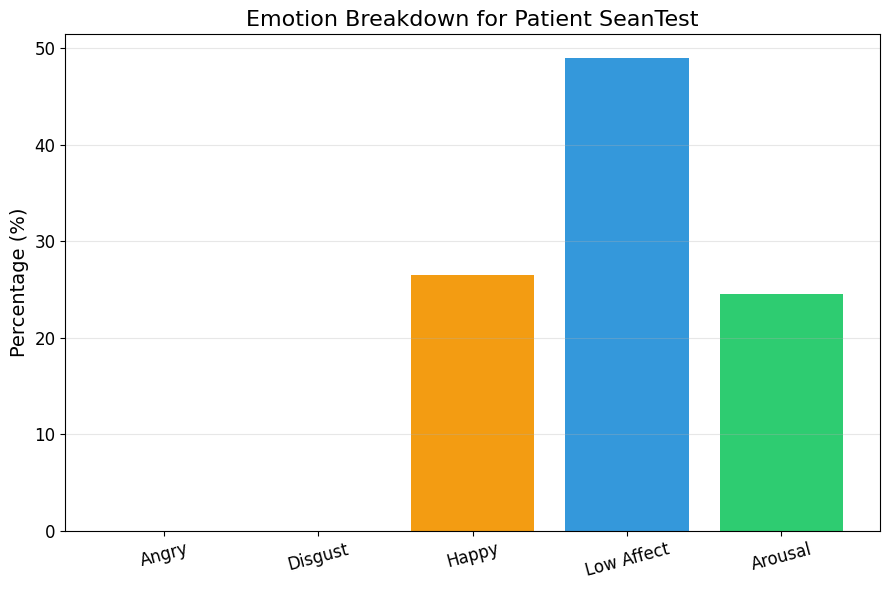

In [5]:
# Bar chart

colors = ['#e74c3c', '#9b59b6', '#f39c12', '#3498db', '#2ecc71']

plt.figure(figsize=(9, 6))
plt.bar(display_labels, percents, color=colors)
plt.ylabel("Percentage (%)", fontsize=14)
plt.title(f"Emotion Breakdown for Patient {patient_id}", fontsize=16)
plt.xticks(rotation=15, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Found 2 visits for patient SeanTest


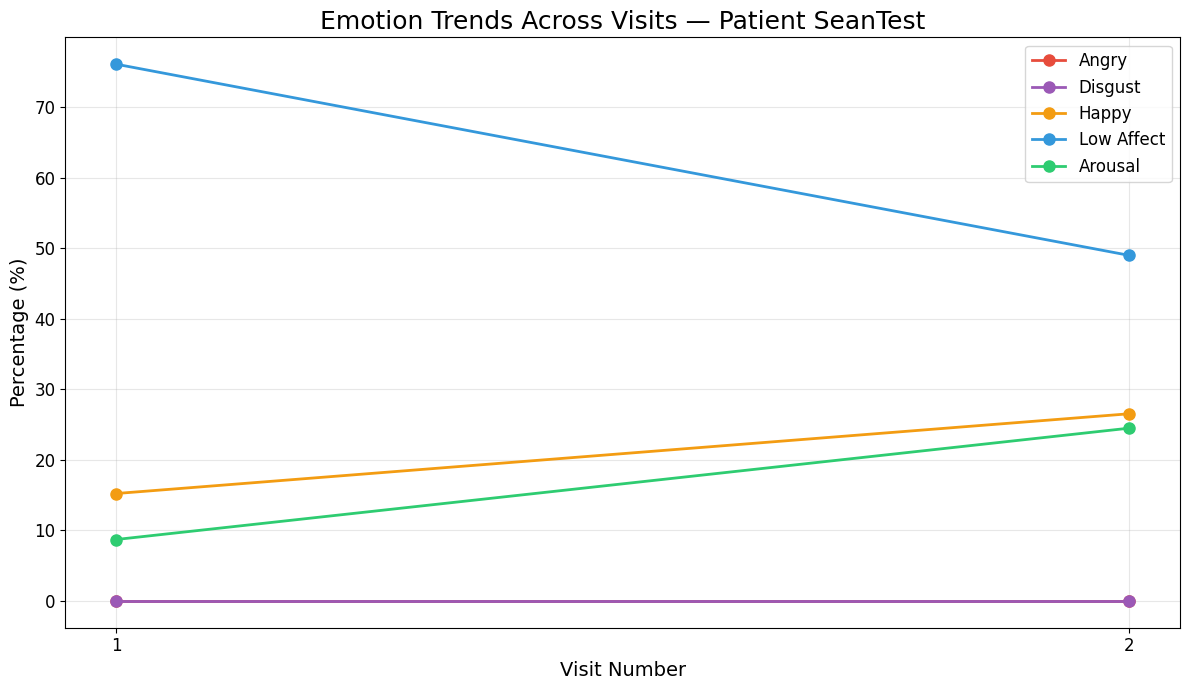

In [6]:
# 3. Serial Trend Analysis (Across visit history)

# Sort visits for one patient
patient_df = df[df["patient_id"] == patient_id].sort_values("timestamp").copy()
patient_df["visit_number"] = range(1, len(patient_df) + 1)

print(f"\nFound {len(patient_df)} visits for patient {patient_id}")

if len(patient_df) > 1:
    # Plot emotion trends over visits
    plt.figure(figsize=(12, 7))
    
    colors = ['#e74c3c', '#9b59b6', '#f39c12', '#3498db', '#2ecc71']
    
    for emo, display_label, color in zip(emotion_labels, display_labels, colors):
        plt.plot(
            patient_df["visit_number"],
            patient_df[f"{emo}_pct"],
            marker="o",
            label=display_label,
            color=color,
            linewidth=2,
            markersize=8
        )
    
    plt.title(f"Emotion Trends Across Visits — Patient {patient_id}", fontsize=18)
    plt.xlabel("Visit Number", fontsize=14)
    plt.ylabel("Percentage (%)", fontsize=14)
    plt.legend(fontsize=12)
    plt.xticks(patient_df["visit_number"], fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Only one visit found. Need multiple visits for trend analysis.")

In [7]:
# 4. Dominant emotion per visit

pct_cols = [f"{emo}_pct" for emo in emotion_labels]
patient_df["dominant_emotion"] = (
    patient_df[pct_cols]
    .idxmax(axis=1)
    .str.replace("_pct", "")
    .str.replace("_", " ")
    .str.title()
)

print("\nDominant emotion per visit:")
display_df = patient_df[["visit_number", "visit_label", "dominant_emotion", "t_end", "total_samples"]].copy()
display_df.columns = ["Visit #", "Date", "Dominant Emotion", "Duration (s)", "Samples"]
display_df


Dominant emotion per visit:


,Visit #,Date,Dominant Emotion,Duration (s),Samples
0,1,2026-03-11,Low Affect,25.551045,46
1,2,2026-03-11,Low Affect,27.495419,49


In [8]:
# 5. Summary statistics across all visits for this patient

print(f"\n{'='*60}")
print(f"SUMMARY STATISTICS - Patient {patient_id}")
print(f"{'='*60}")
print(f"Total visits: {len(patient_df)}")
print(f"Total samples analyzed: {patient_df['total_samples'].sum()}")
print(f"Average samples per visit: {patient_df['total_samples'].mean():.1f}")
print(f"Average visit duration: {patient_df['t_end'].mean():.1f}s")
print(f"\nAverage emotion distribution across all visits:")
for emo, label in zip(emotion_labels, display_labels):
    avg_pct = patient_df[f"{emo}_pct"].mean()
    print(f"  {label:15} {avg_pct:6.2f}%")
print(f"{'='*60}")


SUMMARY STATISTICS - Patient SeanTest
Total visits: 2
Total samples analyzed: 95
Average samples per visit: 47.5
Average visit duration: 26.5s

Average emotion distribution across all visits:
  Angry             0.00%
  Disgust           0.00%
  Happy            20.88%
  Low Affect       62.53%
  Arousal          16.59%
